In [56]:
#Prompt:acesse o https://github.com/rfranceli-doc/series_temporais_mba_eca, a capture os dados do dataset 09.IBOV-1997-2025.csv

import pandas as pd

# Construct the raw GitHub URL for the dataset
url = 'https://raw.githubusercontent.com/rfranceli-doc/series_temporais_mba_eca/main/09.IBOV-1997-2025.csv'

# Load the dataset using semicolon as separator and latin1 encoding
df = pd.read_csv(url, sep=';', encoding='latin1')

# Display the first 5 rows of the DataFrame
print(df.head())

   Mês   Ano      Valor
0    1  1997   7.964,69
1    2  1997   8.828,73
2    3  1997   9.044,35
3    4  1997   9.982,39
4    5  1997  11.344,83


In [57]:
#Prompt: transforme em série temporal, utilizando o campo Mês e Ano para construir o índice de tempo
import pandas as pd

# Create a 'Data' column by combining Year and Month
# We assume the day is the first of the month
df['Data'] = pd.to_datetime(df['Ano'].astype(str) + '-' + df['Mês'].astype(str) + '-01')

# Clean the 'Valor' column: remove thousands separator (dot) and replace decimal comma with dot
df['Valor'] = df['Valor'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Set 'Data' as the index and keep only 'Valor'
ts = df.set_index('Data')[['Valor']]

# Display the time series
display(ts.head())
print(ts.info())

,Valor
Data,
1997-01-01,7964.69
1997-02-01,8828.73
1997-03-01,9044.35
1997-04-01,9982.39
1997-05-01,11344.83


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 343 entries, 1997-01-01 to 2025-07-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Valor   343 non-null    float64
dtypes: float64(1)
memory usage: 5.4 KB
None


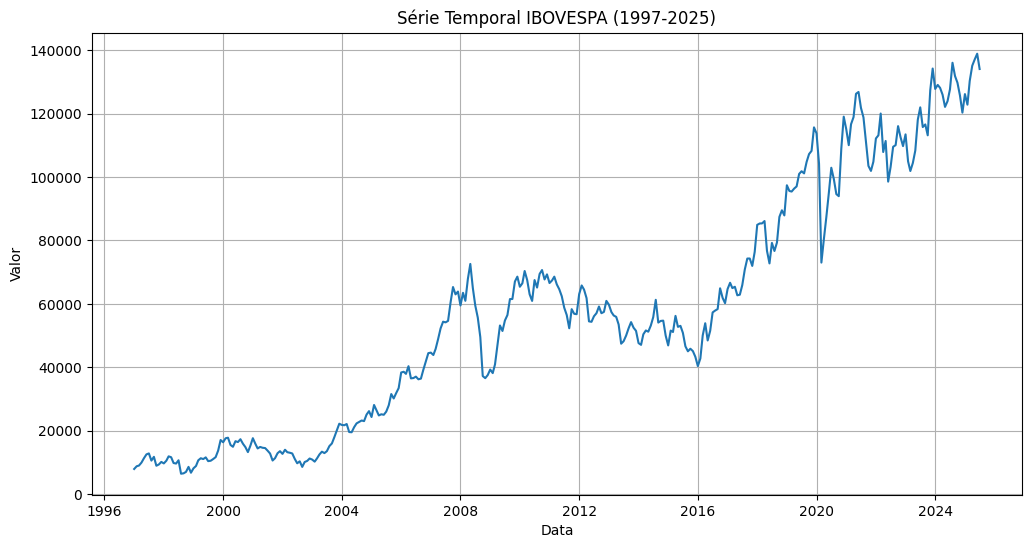

In [58]:
#prompt:plote a série
import matplotlib.pyplot as plt

# Quick visualization of the time series
plt.figure(figsize=(12, 6))
plt.plot(ts.index, ts['Valor'])
plt.title('Série Temporal IBOVESPA (1997-2025)')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.grid(True)
plt.show()

In [59]:
#Prompt: separe os dados em treino e teste (70/30)
# Calculate the split point (70% for training)
split_point = int(len(ts) * 0.7)

# Split the data chronologically
train = ts.iloc[:split_point]
test = ts.iloc[split_point:]

print(f"Tamanho total: {len(ts)}")
print(f"Dados de Treino: {len(train)} (de {train.index.min().date()} a {train.index.max().date()})")
print(f"Dados de Teste: {len(test)} (de {test.index.min().date()} a {test.index.max().date()})")

# Display the split
train.tail()

Tamanho total: 343
Dados de Treino: 240 (de 1997-01-01 a 2016-12-01)
Dados de Teste: 103 (de 2017-01-01 a 2025-07-01)


,Valor
Data,
2016-08-01,57901.10
2016-09-01,58367.04
2016-10-01,64924.51
2016-11-01,61906.35
2016-12-01,60227.28


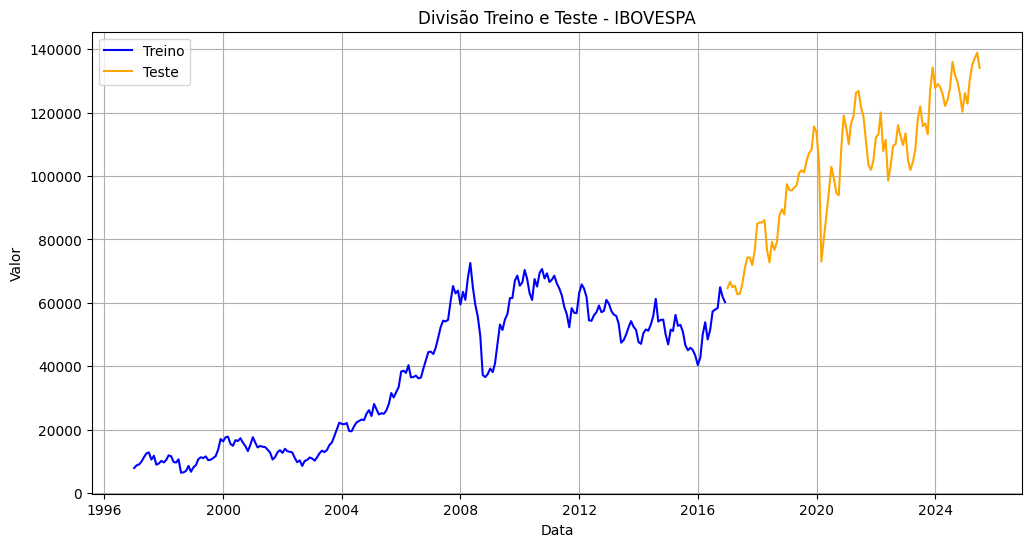

In [60]:
#Prompt: plote as duas séries
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Valor'], label='Treino', color='blue')
plt.plot(test.index, test['Valor'], label='Teste', color='orange')

plt.title('Divisão Treino e Teste - IBOVESPA')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

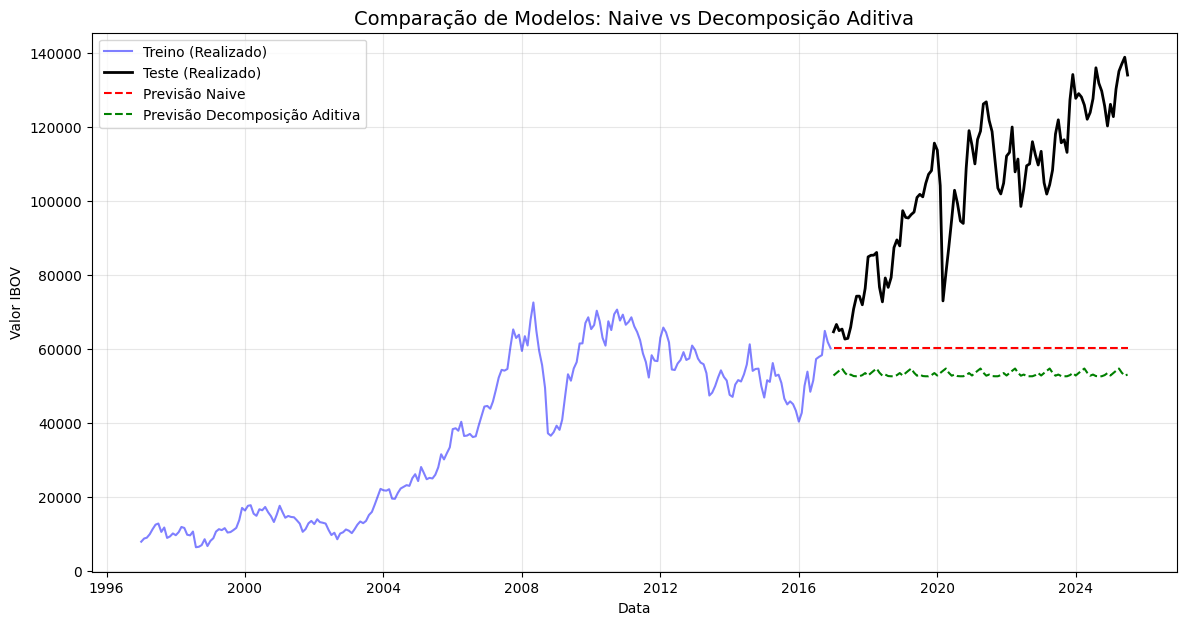

In [61]:
#Prompt: utilize os dados de treino para modelar uma decomposição aditiva e uma projeção naive, plote ambas

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Naive Model: Predict the last value of the training set for the whole test period
last_train_value = train['Valor'].iloc[-1]
naive_forecast = np.full(len(test), last_train_value)

# 2. Additive Decomposition Model
# We assume a frequency of 12 (monthly data)
decomposition = seasonal_decompose(train['Valor'], model='additive', period=12)

# To forecast with decomposition, we typically extrapolate the trend and repeat seasonality
# For simplicity in this visualization, we'll project the trend as a constant (last known trend)
# plus the seasonal component
last_trend = decomposition.trend.dropna().iloc[-1]
seasonal_cycle = decomposition.seasonal[-12:].values

# Project seasonality for the test period length
seasonal_forecast = np.tile(seasonal_cycle, int(np.ceil(len(test)/12)))[:len(test)]
decomp_forecast = last_trend + seasonal_forecast

# Plotting
plt.figure(figsize=(14, 7))

# Actual Data
plt.plot(train.index, train['Valor'], label='Treino (Realizado)', color='blue', alpha=0.5)
plt.plot(test.index, test['Valor'], label='Teste (Realizado)', color='black', linewidth=2)

# Forecasts
plt.plot(test.index, naive_forecast, label='Previsão Naive', color='red', linestyle='--')
plt.plot(test.index, decomp_forecast, label='Previsão Decomposição Aditiva', color='green', linestyle='--')

plt.title('Comparação de Modelos: Naive vs Decomposição Aditiva', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Valor IBOV')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


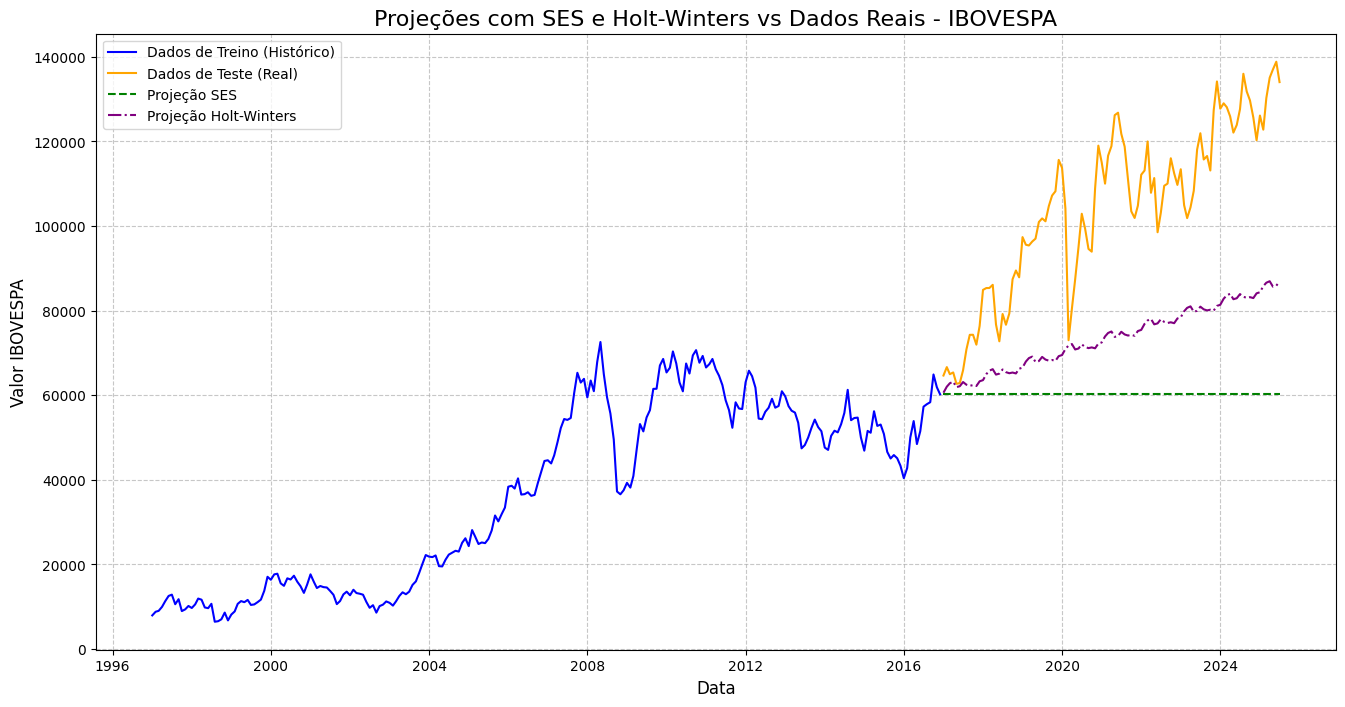

In [62]:
#Prompt: gere uma projeção utilizando somente os dados de treino com SES e holt-winters, plote os resultados
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Modelo Simple Exponential Smoothing (SES) ---
# SES é adequado para dados sem tendência e sazonalidade. Aplica-se aos dados de treino.
fit_ses = SimpleExpSmoothing(train['Valor'], initialization_method="estimated").fit()
forecast_ses = fit_ses.forecast(len(test))

# --- 2. Modelo Holt-Winters (Triple Exponential Smoothing) ---
# Holt-Winters é adequado para dados com tendência e sazonalidade. Para isso, usamos ExponentialSmoothing.
# Usaremos uma sazonalidade aditiva com período de 12 meses, como na decomposição anterior.
fit_hw = ExponentialSmoothing(train['Valor'],
                              trend='add',
                              seasonal='add',
                              seasonal_periods=12,
                              initialization_method="estimated").fit()
forecast_hw = fit_hw.forecast(len(test))

# --- 3. Plotagem dos Resultados ---
plt.figure(figsize=(16, 8))
plt.plot(train.index, train['Valor'], label='Dados de Treino (Histórico)', color='blue')
plt.plot(test.index, test['Valor'], label='Dados de Teste (Real)', color='orange')
plt.plot(forecast_ses.index, forecast_ses, label='Projeção SES', color='green', linestyle='--')
plt.plot(forecast_hw.index, forecast_hw, label='Projeção Holt-Winters', color='purple', linestyle='-.')

plt.title('Projeções com SES e Holt-Winters vs Dados Reais - IBOVESPA', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Valor IBOVESPA', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

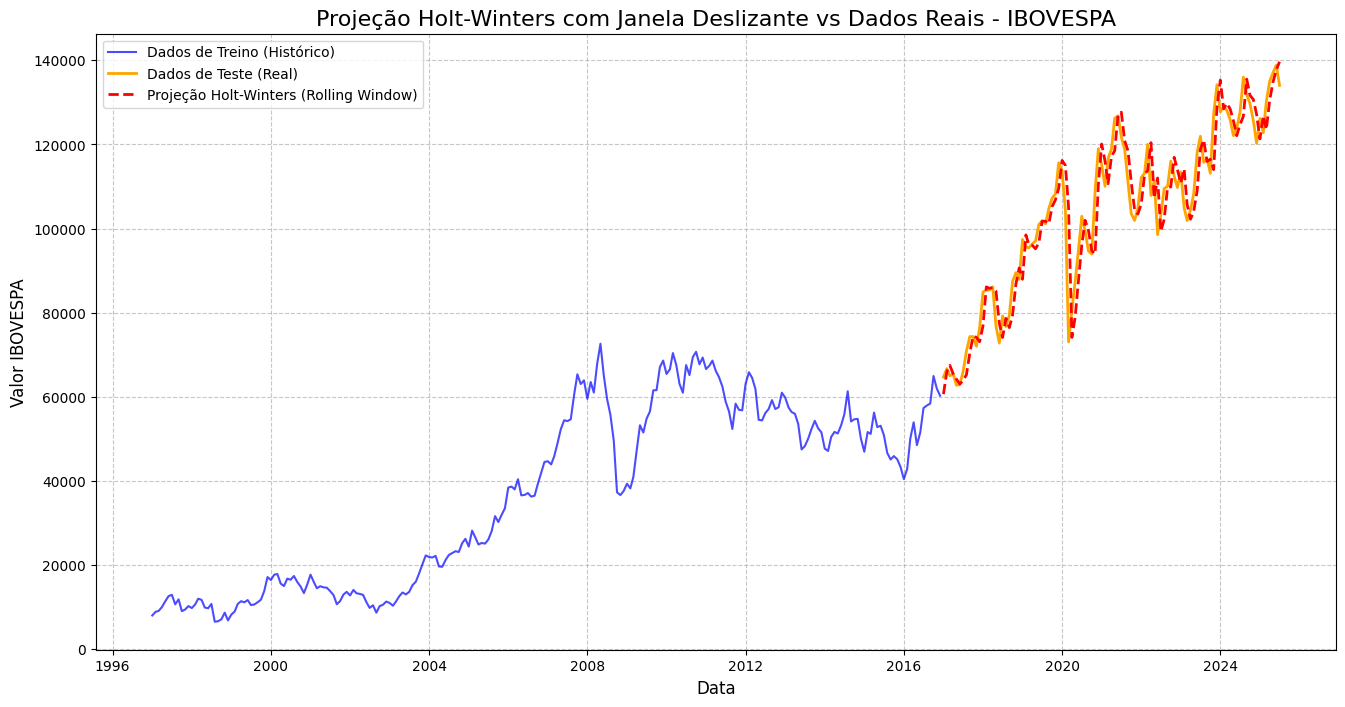

In [63]:
#Prompt: faça a projeção utilizando holt-winters do período de teste, mas dessa vez, utiliza rolling window para a atualização do input
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import pandas as pd

# Lista para armazenar as previsões do modelo Holt-Winters com janela deslizante
rolling_hw_forecasts = []

# Começa com os dados de treino completos
current_train_data = train['Valor'].copy()

# Loop pelo período de teste para realizar a previsão com janela deslizante
for i in range(len(test)):
    # Define o modelo Holt-Winters (aditivo para tendência e sazonalidade)
    # Usamos initialization_method="estimated" para que os parâmetros sejam estimados automaticamente
    model_hw = ExponentialSmoothing(current_train_data,
                                    trend='add',
                                    seasonal='add',
                                    seasonal_periods=12,
                                    initialization_method="estimated")

    # Ajusta o modelo aos dados atuais de treino
    fit_hw_rolling = model_hw.fit()

    # Preveja apenas o próximo ponto (um passo à frente)
    next_forecast = fit_hw_rolling.forecast(1)
    rolling_hw_forecasts.append(next_forecast.iloc[0])

    # Adiciona o valor real do período de teste aos dados de treino para a próxima iteração
    # Isso simula a "observação" de novos dados
    next_test_value_series = pd.Series([test['Valor'].iloc[i]], index=[test.index[i]])
    current_train_data = pd.concat([current_train_data, next_test_value_series])

# Converte a lista de previsões em uma série pandas com o índice do período de teste
rolling_hw_forecast_series = pd.Series(rolling_hw_forecasts, index=test.index)

# Plotagem dos resultados
plt.figure(figsize=(16, 8))
plt.plot(train.index, train['Valor'], label='Dados de Treino (Histórico)', color='blue', alpha=0.7)
plt.plot(test.index, test['Valor'], label='Dados de Teste (Real)', color='orange', linewidth=2)
plt.plot(rolling_hw_forecast_series.index, rolling_hw_forecast_series, label='Projeção Holt-Winters (Rolling Window)', color='red', linestyle='--', linewidth=2)

plt.title('Projeção Holt-Winters com Janela Deslizante vs Dados Reais - IBOVESPA', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Valor IBOVESPA', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Projeção Holt-Winters com Re-estimação de Coeficientes (Rolling Window)
Nesta etapa, percorremos o conjunto de teste um passo por vez. Para cada novo mês:
1. Ajustamos o modelo Holt-Winters aos dados disponíveis até aquele momento.
2. Permitimos que o algoritmo reestime os parâmetros $\alpha, \beta, \gamma$ (coeficientes de nível, tendência e sazonalidade).
3. Projetamos o próximo valor e o comparamos com o real.

Iniciando previsões com re-estimação de coeficientes...


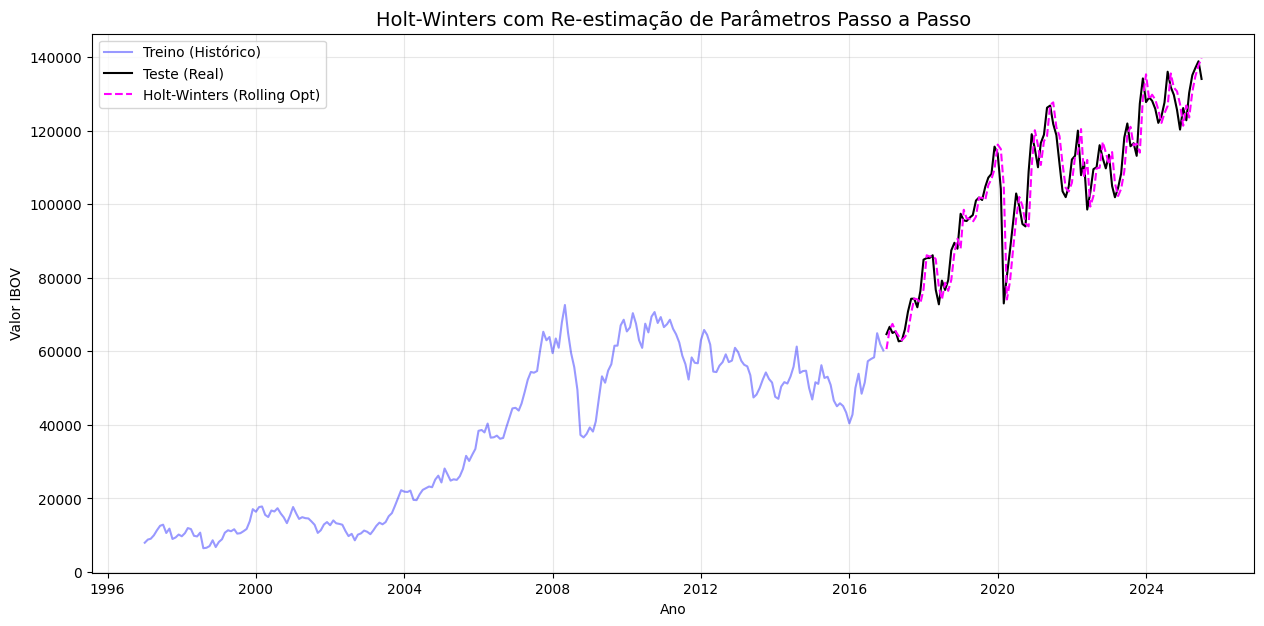

In [64]:
#Prompt: faça a projeção utilizando holt-winters do período de teste, mas dessa vez, utilize rolling window para a atualização do input e dos coeficientes
#já foi feito na célula anterior
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

# Preparação das listas para coletar resultados
predictions_rolling_opt = []
history = list(train['Valor'])

print("Iniciando previsões com re-estimação de coeficientes...")

# Loop de Janela Deslizante (Rolling Window)
for i in range(len(test)):
    # Criar e ajustar o modelo com os dados atuais (histórico + observações de teste anteriores)
    # O método 'fit()' sem parâmetros pré-definidos força a re-estimação dos coeficientes
    model = ExponentialSmoothing(history,
                                 trend='add',
                                 seasonal='add',
                                 seasonal_periods=12)

    # Ajuste otimizando os parâmetros internamente
    model_fit = model.fit(optimized=True)

    # Prever o próximo passo
    yhat = model_fit.forecast(1)[0]
    predictions_rolling_opt.append(yhat)

    # Observar o valor real e adicionar ao histórico para o próximo passo
    actual = test['Valor'].iloc[i]
    history.append(actual)

# Transformar em Série para facilitar a plotagem
rolling_opt_series = pd.Series(predictions_rolling_opt, index=test.index)

# Visualização dos Resultados
plt.figure(figsize=(15, 7))
plt.plot(train.index, train['Valor'], label='Treino (Histórico)', color='blue', alpha=0.4)
plt.plot(test.index, test['Valor'], label='Teste (Real)', color='black', linewidth=1.5)
plt.plot(rolling_opt_series.index, rolling_opt_series, label='Holt-Winters (Rolling Opt)', color='magenta', linestyle='--')

plt.title('Holt-Winters com Re-estimação de Parâmetros Passo a Passo', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Valor IBOV')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [65]:
#Prompt: apresente o rmse das três projeções realizadas com o holt-winters
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. RMSE do Holt-Winters Estático (Variável forecast_hw)
rmse_static = np.sqrt(mean_squared_error(test['Valor'], forecast_hw))

# 2. RMSE do Holt-Winters Rolling Window (Variável rolling_hw_forecast_series)
rmse_rolling = np.sqrt(mean_squared_error(test['Valor'], rolling_hw_forecast_series))

# 3. RMSE do Holt-Winters Rolling com Re-estimação (Variável rolling_opt_series)
rmse_rolling_opt = np.sqrt(mean_squared_error(test['Valor'], rolling_opt_series))

# Criando um DataFrame para exibição comparativa
rmse_comparison = pd.DataFrame({
    'Modelo Holt-Winters': ['Estático (Treino Base)', 'Rolling (Novos Dados)', 'Rolling Otimizado (Novos Dados + Coeficientes)'],
    'RMSE': [rmse_static, rmse_rolling, rmse_rolling_opt]
})

print("Comparativo de Performance (RMSE):")
display(rmse_comparison)

Comparativo de Performance (RMSE):


,Modelo Holt-Winters,RMSE
0,Estático (Treino Base),33675.539662
1,Rolling (Novos Dados),6241.972805
2,Rolling Otimizado (Novos Dados + Coeficientes),6241.972805


In [66]:
#Prompt: faça os testes de estacionariedade adf, kpss, pp e df-gls na série ibov completa
!pip install arch -q
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron, DFGLS

# Função para formatar os resultados de forma organizada
def print_test_results(name, statistic, p_value, crit_values, null_hypothesis):
    print(f"--- {name} ---")
    print(f"Hipotese Nula: {null_hypothesis}")
    print(f"Estatística do Teste: {statistic:.4f}")
    print(f"p-valor: {p_value:.4f}" if p_value is not None else "p-valor: N/A")
    print("Valores Críticos:")
    for key, val in crit_values.items():
        print(f"   {key}: {val:.4f}")
    print("\n")

# 1. ADF Test
adf_res = adfuller(ts['Valor'])
print_test_results("Augmented Dickey-Fuller (ADF)", adf_res[0], adf_res[1], adf_res[4], "A série possui raiz unitária (não estacionária)")

# 2. KPSS Test
# Nota: No KPSS, p-valor baixo significa que REJEITAMOS a estacionariedade.
kpss_res = kpss(ts['Valor'], regression='c')
print_test_results("KPSS", kpss_res[0], kpss_res[1], kpss_res[3], "A série é estacionária")

# 3. Phillips-Perron (PP)
pp_test = PhillipsPerron(ts['Valor'])
print_test_results("Phillips-Perron (PP)", pp_test.stat, pp_test.pvalue, pp_test.critical_values, "A série possui raiz unitária (não estacionária)")

# 4. DF-GLS
df_gls_test = DFGLS(ts['Valor'])
print_test_results("DF-GLS", df_gls_test.stat, df_gls_test.pvalue, df_gls_test.critical_values, "A série possui raiz unitária (não estacionária)")

--- Augmented Dickey-Fuller (ADF) ---
Hipotese Nula: A série possui raiz unitária (não estacionária)
Estatística do Teste: 0.0743
p-valor: 0.9643
Valores Críticos:
   1%: -3.4498
   5%: -2.8701
   10%: -2.5713


--- KPSS ---
Hipotese Nula: A série é estacionária
Estatística do Teste: 2.6450
p-valor: 0.0100
Valores Críticos:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


--- Phillips-Perron (PP) ---
Hipotese Nula: A série possui raiz unitária (não estacionária)
Estatística do Teste: 0.1309
p-valor: 0.9681
Valores Críticos:
   1%: -3.4496
   5%: -2.8700
   10%: -2.5713


--- DF-GLS ---
Hipotese Nula: A série possui raiz unitária (não estacionária)
Estatística do Teste: 1.5694
p-valor: 0.9723
Valores Críticos:
   1%: -2.6271
   5%: -2.0057
   10%: -1.6862




/tmp/ipykernel_2549/2073131619.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(ts['Valor'], regression='c')


In [67]:
#Prompt: gere uma série diferenciada da serie completa ibov e faça os mesmos 4 testes de estacionariedade
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron, DFGLS

# Criando a série diferenciada (Primeira Diferença)
ts_diff = ts['Valor'].diff().dropna()

# Função para formatar os resultados
def print_test_results(name, statistic, p_value, crit_values, null_hypothesis):
    print(f"--- {name} (Série Diferenciada) ---")
    print(f"Hipotese Nula: {null_hypothesis}")
    print(f"Estatística do Teste: {statistic:.4f}")
    print(f"p-valor: {p_value:.4f}" if p_value is not None else "p-valor: N/A")
    print("Valores Críticos:")
    for key, val in crit_values.items():
        print(f"   {key}: {val:.4f}")
    print("\n")

# 1. ADF Test
adf_diff = adfuller(ts_diff)
print_test_results("ADF", adf_diff[0], adf_diff[1], adf_diff[4], "Possui raiz unitária")

# 2. KPSS Test
kpss_diff = kpss(ts_diff, regression='c')
print_test_results("KPSS", kpss_diff[0], kpss_diff[1], kpss_diff[3], "A série é estacionária")

# 3. Phillips-Perron (PP)
pp_diff = PhillipsPerron(ts_diff)
print_test_results("Phillips-Perron (PP)", pp_diff.stat, pp_diff.pvalue, pp_diff.critical_values, "Possui raiz unitária")

# 4. DF-GLS
df_gls_diff = DFGLS(ts_diff)
print_test_results("DF-GLS", df_gls_diff.stat, df_gls_diff.pvalue, df_gls_diff.critical_values, "Possui raiz unitária")

--- ADF (Série Diferenciada) ---
Hipotese Nula: Possui raiz unitária
Estatística do Teste: -11.8501
p-valor: 0.0000
Valores Críticos:
   1%: -3.4498
   5%: -2.8701
   10%: -2.5713


--- KPSS (Série Diferenciada) ---
Hipotese Nula: A série é estacionária
Estatística do Teste: 0.0895
p-valor: 0.1000
Valores Críticos:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


--- Phillips-Perron (PP) (Série Diferenciada) ---
Hipotese Nula: Possui raiz unitária
Estatística do Teste: -17.4951
p-valor: 0.0000
Valores Críticos:
   1%: -3.4497
   5%: -2.8701
   10%: -2.5713


--- DF-GLS (Série Diferenciada) ---
Hipotese Nula: Possui raiz unitária
Estatística do Teste: -11.6426
p-valor: 0.0000
Valores Críticos:
   1%: -2.6271
   5%: -2.0057
   10%: -1.6862




/tmp/ipykernel_2549/271761796.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff = kpss(ts_diff, regression='c')


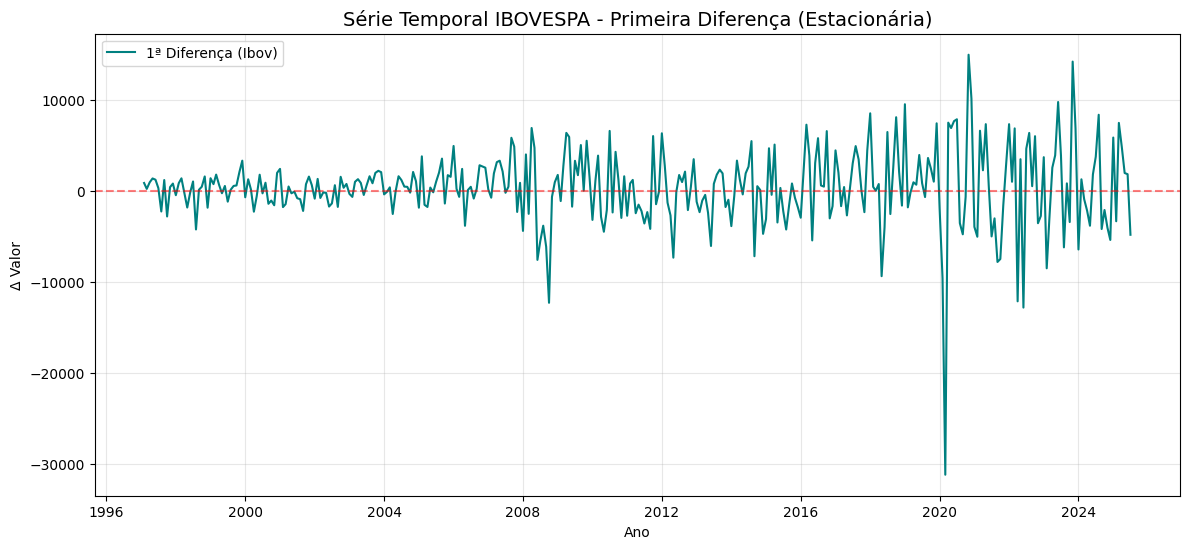

In [68]:
#Prompt: plote a série diferenciada
import matplotlib.pyplot as plt

# Plotagem da série diferenciada
plt.figure(figsize=(14, 6))
plt.plot(ts_diff.index, ts_diff, color='teal', label='1ª Diferença (Ibov)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Série Temporal IBOVESPA - Primeira Diferença (Estacionária)', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Δ Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

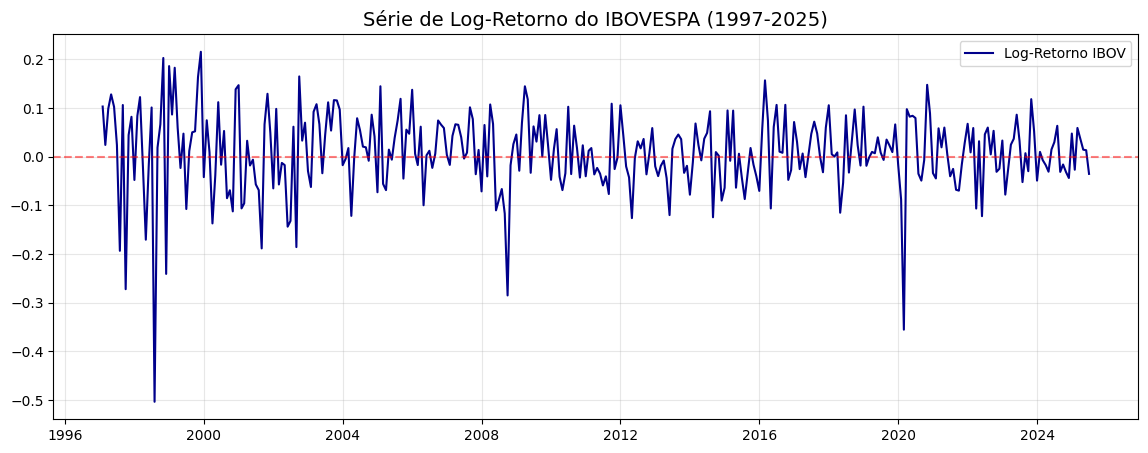

RESULTADOS DOS TESTES DE ESTACIONARIEDADE (LOG-RETORNO):

--- ADF (Log-Retorno) ---
Hipotese Nula: Raiz Unitária
Estatística: -18.0129 | p-valor: 0.0000
Valores Críticos (5%): -2.8701

--- KPSS (Log-Retorno) ---
Hipotese Nula: Série Estacionária
Estatística: 0.0722 | p-valor: 0.1000
Valores Críticos (5%): 0.4630

--- PP (Log-Retorno) ---
Hipotese Nula: Raiz Unitária
Estatística: -18.2345 | p-valor: 0.0000
Valores Críticos (5%): -2.8701

--- DF-GLS (Log-Retorno) ---
Hipotese Nula: Raiz Unitária
Estatística: -10.4957 | p-valor: 0.0000
Valores Críticos (5%): -2.0052



/tmp/ipykernel_2549/3153364301.py:28: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_lr = kpss(ts_log_ret, regression='c')


In [69]:
#Prompt: gere uma série do log-retorno da ibov completa e faça os testes de estacionariedade
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron, DFGLS

# 1. Calculando o Log-Retorno: log(Pt / Pt-1)
ts_log_ret = np.log(ts['Valor'] / ts['Valor'].shift(1)).dropna()

# 2. Plotagem para inspeção visual
plt.figure(figsize=(14, 5))
plt.plot(ts_log_ret.index, ts_log_ret, color='darkblue', label='Log-Retorno IBOV')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Série de Log-Retorno do IBOVESPA (1997-2025)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 3. Função para exibir resultados (reaproveitando a lógica anterior)
def print_log_ret_results(name, statistic, p_value, crit_values, null_hypothesis):
    print(f"--- {name} (Log-Retorno) ---")
    print(f"Hipotese Nula: {null_hypothesis}")
    print(f"Estatística: {statistic:.4f} | p-valor: {p_value:.4f}" if p_value is not None else f"Estatística: {statistic:.4f}")
    print(f"Valores Críticos (5%): {crit_values['5%']:.4f}\n")

# Executando os testes
adf_lr = adfuller(ts_log_ret)
kpss_lr = kpss(ts_log_ret, regression='c')
pp_lr = PhillipsPerron(ts_log_ret)
dfgls_lr = DFGLS(ts_log_ret)

print("RESULTADOS DOS TESTES DE ESTACIONARIEDADE (LOG-RETORNO):\n")
print_log_ret_results("ADF", adf_lr[0], adf_lr[1], adf_lr[4], "Raiz Unitária")
print_log_ret_results("KPSS", kpss_lr[0], kpss_lr[1], kpss_lr[3], "Série Estacionária")
print_log_ret_results("PP", pp_lr.stat, pp_lr.pvalue, pp_lr.critical_values, "Raiz Unitária")
print_log_ret_results("DF-GLS", dfgls_lr.stat, dfgls_lr.pvalue, dfgls_lr.critical_values, "Raiz Unitária")

In [70]:
#Prompt: acesse o https://github.com/rfranceli-doc/series_temporais_mba_eca e carregue o arquivo 00.BaseVolume.xlsx, Planilha2, e substitua o nome da coluna Usuários por Mes
import pandas as pd

# URL do arquivo Excel no GitHub (raw)
url_excel = 'https://github.com/rfranceli-doc/series_temporais_mba_eca/raw/main/00.BaseVolume.xlsx'

# Carregando a Planilha2
df_volume = pd.read_excel(url_excel, sheet_name='Planilha2')

# Renomeando a coluna 'Usuários' para 'Mes'
df_volume = df_volume.rename(columns={'Usuários': 'Mes'})

# Exibindo as primeiras linhas para conferência
display(df_volume.head())
print(df_volume.info())

,Mes,Clientes Cativo - Residencial Individual,Clientes Cativo - Residencial Coletivo,Clientes Cativo - Comercial,Clientes Industrial,Clientes GNV - Postos / Transporte Público / Frotas,Clientes GNV - Postos,Clientes GNV - Transporte Público,Clientes GNV - Frotas,Clientes Cogeração,...,Volume GNV - Transporte Público,Volume GNV - Frotas,Volume Cogeração,Volume Refrigeração,Volume GNL,Volume Interruptível,Volume Alto Fator de Carga,Volume GNC,Volume Cativo - Termelétrica,Volume Total Não Térmico
0,2018-06-01,1213427,593175,30238,1262,264,263,0,1,30,...,0,29749.194,27780115.95,573388.98,0.0,0,35990222.49,1008.50,0.0,3.773361e+08
1,2018-07-01,1226778,598866,30733,1262,256,255,0,1,30,...,0,23302.640,27041542.96,503104.22,0.0,0,33923918.71,666151.89,0.0,3.791300e+08
2,2018-08-01,1231764,599669,30710,1276,260,259,0,1,31,...,0,27748.700,27034222.50,444445.49,0.0,0,36628435.31,429473.44,0.0,4.088753e+08
3,2018-09-01,1229575,639991,30969,1259,265,264,0,1,30,...,0,27665.640,29449536.66,505325.46,0.0,0,36733139.91,298889.05,0.0,4.102745e+08
4,2018-10-01,1243986,611396,30602,1295,258,257,0,1,30,...,0,30360.720,30120140.86,603130.41,0.0,0,32562259.44,307263.00,0.0,3.870343e+08


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 33 columns):
 #   Column                                               Non-Null Count  Dtype         
---  ------                                               --------------  -----         
 0   Mes                                                  78 non-null     datetime64[ns]
 1   Clientes Cativo - Residencial Individual             78 non-null     int64         
 2   Clientes Cativo - Residencial Coletivo               78 non-null     int64         
 3   Clientes Cativo - Comercial                          78 non-null     int64         
 4   Clientes Industrial                                  78 non-null     int64         
 5   Clientes GNV - Postos / Transporte Público / Frotas  78 non-null     int64         
 6   Clientes GNV - Postos                                78 non-null     int64         
 7   Clientes GNV - Transporte Público                    78 non-null     int64         
 8   Cl

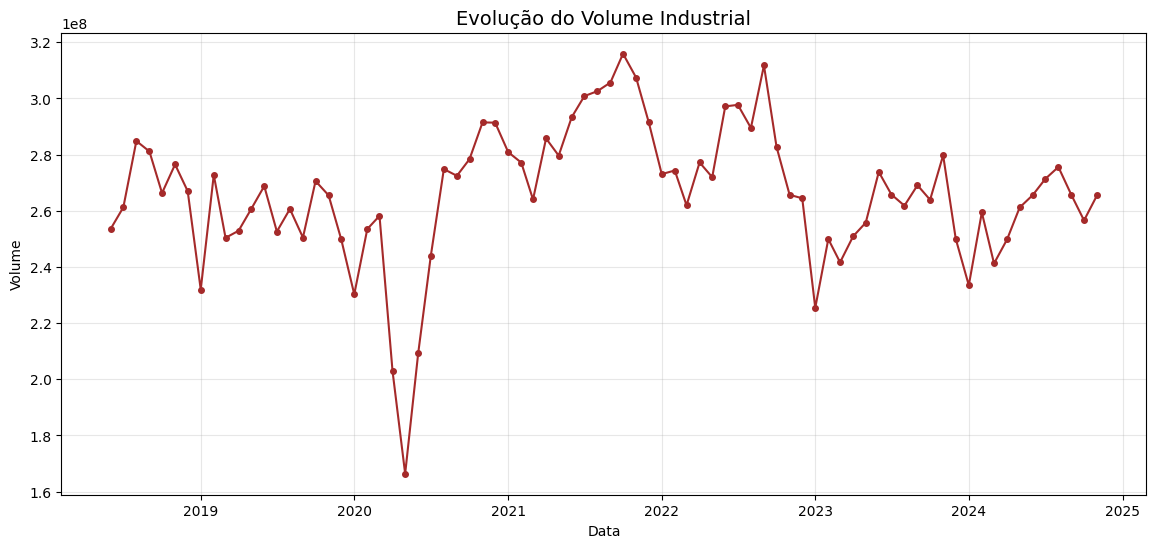

In [71]:
#Prompt: plote a série volume industrial
import matplotlib.pyplot as plt

# Plotagem do Volume Industrial
plt.figure(figsize=(14, 6))
plt.plot(df_volume['Mes'], df_volume['Volume Industrial'], color='brown', marker='o', linestyle='-', markersize=4)
plt.title('Evolução do Volume Industrial', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)
plt.show()

In [72]:
#Prompt: aplique os 4 testes de estacionariedade na série do volume industrial
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron, DFGLS

# Definindo a série
series_volume = df_volume['Volume Industrial']

# Função para formatar os resultados de forma organizada
def print_industrial_results(name, statistic, p_value, crit_values, null_hypothesis):
    print(f"--- {name} (Volume Industrial) ---")
    print(f"Hipotese Nula: {null_hypothesis}")
    print(f"Estatística do Teste: {statistic:.4f}")
    print(f"p-valor: {p_value:.4f}" if p_value is not None else "p-valor: N/A")
    print("Valores Críticos (5%):", f"{crit_values['5%']:.4f}")
    print("\n")

# 1. ADF Test
adf_v = adfuller(series_volume)
print_industrial_results("ADF", adf_v[0], adf_v[1], adf_v[4], "Possui raiz unitária")

# 2. KPSS Test
kpss_v = kpss(series_volume, regression='c')
print_industrial_results("KPSS", kpss_v[0], kpss_v[1], kpss_v[3], "A série é estacionária")

# 3. Phillips-Perron (PP)
pp_v = PhillipsPerron(series_volume)
print_industrial_results("Phillips-Perron (PP)", pp_v.stat, pp_v.pvalue, pp_v.critical_values, "Possui raiz unitária")

# 4. DF-GLS
dfgls_v = DFGLS(series_volume)
print_industrial_results("DF-GLS", dfgls_v.stat, dfgls_v.pvalue, dfgls_v.critical_values, "Possui raiz unitária")

--- ADF (Volume Industrial) ---
Hipotese Nula: Possui raiz unitária
Estatística do Teste: -3.5298
p-valor: 0.0073
Valores Críticos (5%): -2.8999


--- KPSS (Volume Industrial) ---
Hipotese Nula: A série é estacionária
Estatística do Teste: 0.1649
p-valor: 0.1000
Valores Críticos (5%): 0.4630


--- Phillips-Perron (PP) (Volume Industrial) ---
Hipotese Nula: Possui raiz unitária
Estatística do Teste: -3.4942
p-valor: 0.0081
Valores Críticos (5%): -2.8999


--- DF-GLS (Volume Industrial) ---
Hipotese Nula: Possui raiz unitária
Estatística do Teste: -3.3639
p-valor: 0.0008
Valores Críticos (5%): -2.1868




/tmp/ipykernel_2549/149784144.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_v = kpss(series_volume, regression='c')


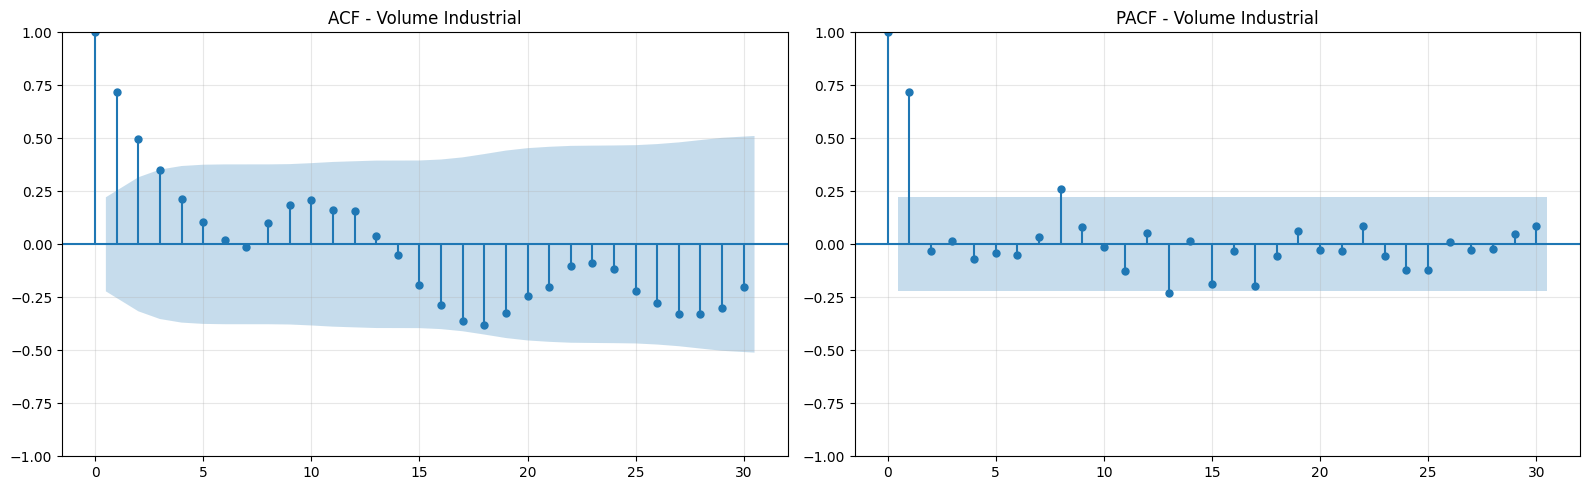

In [73]:
#Prompt: teste o acf e pacf da série
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Configurando a figura para dois subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plotando o ACF (Autocorrelation Function)
plot_acf(df_volume['Volume Industrial'], lags=30, ax=axes[0])
axes[0].set_title('ACF - Volume Industrial')
axes[0].grid(True, alpha=0.3)

# Plotando o PACF (Partial Autocorrelation Function)
plot_pacf(df_volume['Volume Industrial'], lags=30, ax=axes[1], method='ywm')
axes[1].set_title('PACF - Volume Industrial')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:      Volume Industrial   No. Observations:                   78
Model:                 ARIMA(4, 0, 2)   Log Likelihood               -1407.529
Date:                Thu, 14 May 2026   AIC                           2831.058
Time:                        02:42:29   BIC                           2849.912
Sample:                             0   HQIC                          2838.606
                                 - 78                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.661e+08   2.41e-09   1.11e+17      0.000    2.66e+08    2.66e+08
ar.L1         -0.3885      0.130     -2.990      0.003      -0.643      -0.134
ar.L2         -0.1422      0.150     -0.950      0.3

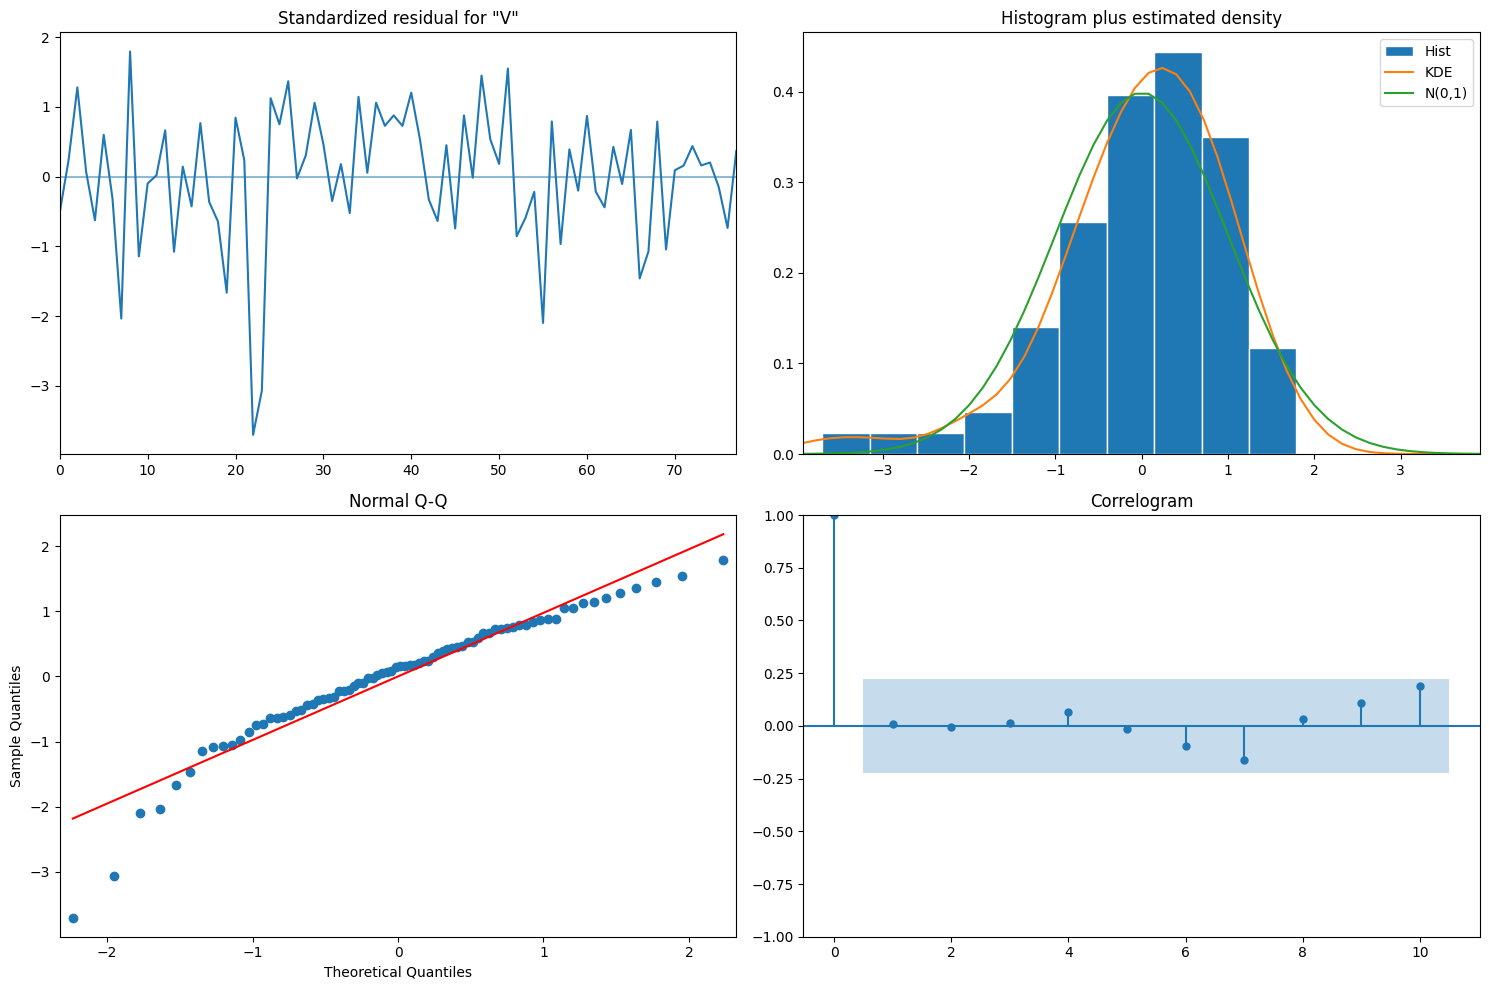

In [74]:
#prompt: gere um modelo arima(4,2)
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Definindo a série
series_volume = df_volume['Volume Industrial']

# Criando o modelo ARIMA(4,0,2)
# d=0 pois a série já é estacionária em nível
model = ARIMA(series_volume, order=(4, 0, 2))
model_fit = model.fit()

# Exibindo o sumário do modelo
print(model_fit.summary())

# Plotando os diagnósticos do modelo
model_fit.plot_diagnostics(figsize=(15, 10))
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:      Volume Industrial   No. Observations:                   78
Model:                 ARIMA(3, 0, 2)   Log Likelihood               -1407.793
Date:                Thu, 14 May 2026   AIC                           2829.586
Time:                        02:42:34   BIC                           2846.083
Sample:                             0   HQIC                          2836.190
                                 - 78                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.661e+08   3.55e-09   7.49e+16      0.000    2.66e+08    2.66e+08
ar.L1         -0.4353      0.158     -2.759      0.006      -0.745      -0.126
ar.L2         -0.1148      0.169     -0.681      0.4

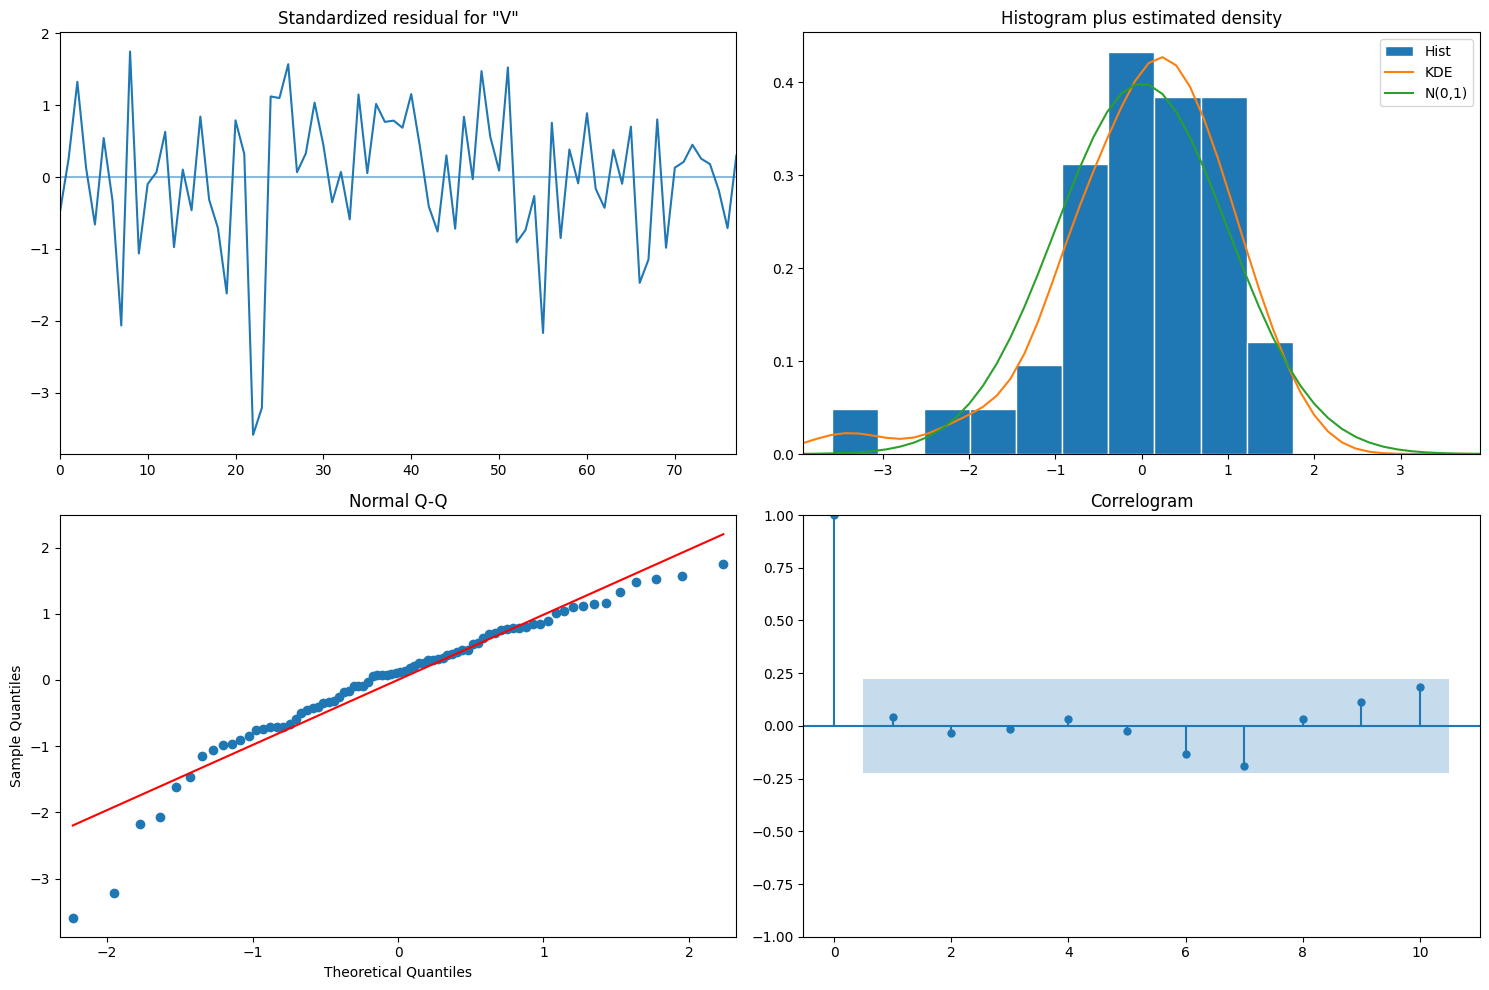

In [75]:
#Prompt: gere um modelo arima(3,2)
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Ajustando o modelo ARIMA(3,0,2)
# d=0 pois os testes de raiz unitária indicaram estacionaridade em nível
model_302 = ARIMA(df_volume['Volume Industrial'], order=(3, 0, 2))
model_fit_302 = model_302.fit()

# Exibindo os resultados
print(model_fit_302.summary())

# Plotando diagnósticos
model_fit_302.plot_diagnostics(figsize=(15, 10))
plt.tight_layout()
plt.show()

In [76]:
#Prompt: calcule o rmse e o mape dos modelos arima(4,0,2) e arima(3,0,2)
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. Cálculos para o modelo ARIMA(4,0,2) - variável 'model_fit'
y_true = df_volume['Volume Industrial']
y_pred_402 = model_fit.fittedvalues

rmse_402 = np.sqrt(mean_squared_error(y_true, y_pred_402))
mape_402 = mean_absolute_percentage_error(y_true, y_pred_402)

# 2. Cálculos para o modelo ARIMA(3,0,2) - variável 'model_fit_302'
y_pred_302 = model_fit_302.fittedvalues

rmse_302 = np.sqrt(mean_squared_error(y_true, y_pred_302))
mape_302 = mean_absolute_percentage_error(y_true, y_pred_302)

# Criando o DataFrame comparativo
metrics_comparison = pd.DataFrame({
    'Métrica': ['RMSE', 'MAPE (%)'],
    'ARIMA(4,0,2)': [rmse_402, mape_402 * 100],
    'ARIMA(3,0,2)': [rmse_302, mape_302 * 100]
})

print("Comparativo de Métricas de Ajuste (In-sample):")
display(metrics_comparison)

Comparativo de Métricas de Ajuste (In-sample):


,Métrica,"ARIMA(4,0,2)","ARIMA(3,0,2)"
0,RMSE,1.659013e+07,1.663954e+07
1,MAPE (%),4.957566e+00,4.977980e+00


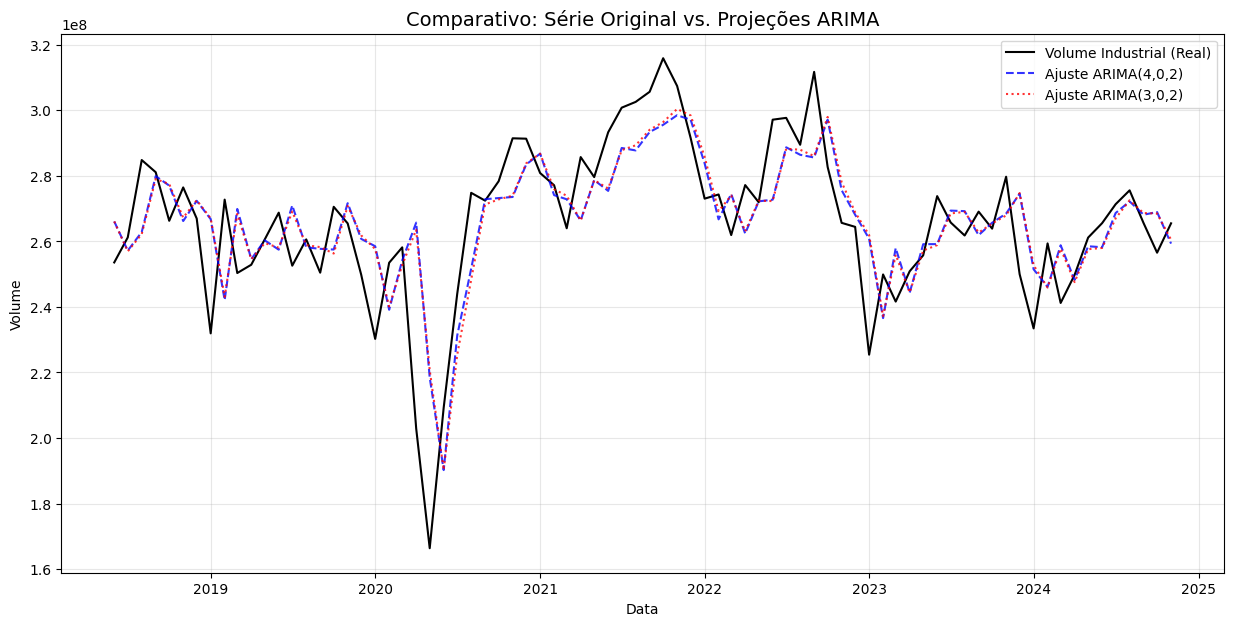

In [77]:
#Prompt: plote a série original e as projeções dos dois modelos arima
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

# Plotando a série original
plt.plot(df_volume['Mes'], df_volume['Volume Industrial'], label='Volume Industrial (Real)', color='black', linewidth=1.5)

# Plotando as projeções (fitted values) dos modelos
# Usamos 'Mes' como eixo X
plt.plot(df_volume['Mes'], y_pred_402, label='Ajuste ARIMA(4,0,2)', color='blue', linestyle='--', alpha=0.8)
plt.plot(df_volume['Mes'], y_pred_302, label='Ajuste ARIMA(3,0,2)', color='red', linestyle=':', alpha=0.8)

plt.title('Comparativo: Série Original vs. Projeções ARIMA', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=2829.182, Time=1.70 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=2877.117, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=2823.293, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=2847.102, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=3250.294, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=2825.214, Time=0.16 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=2825.269, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=2827.217, Time=0.09 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 2.280 seconds

Melhor modelo encontrado pelo auto_arima:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   78
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -1408.647
Date:      

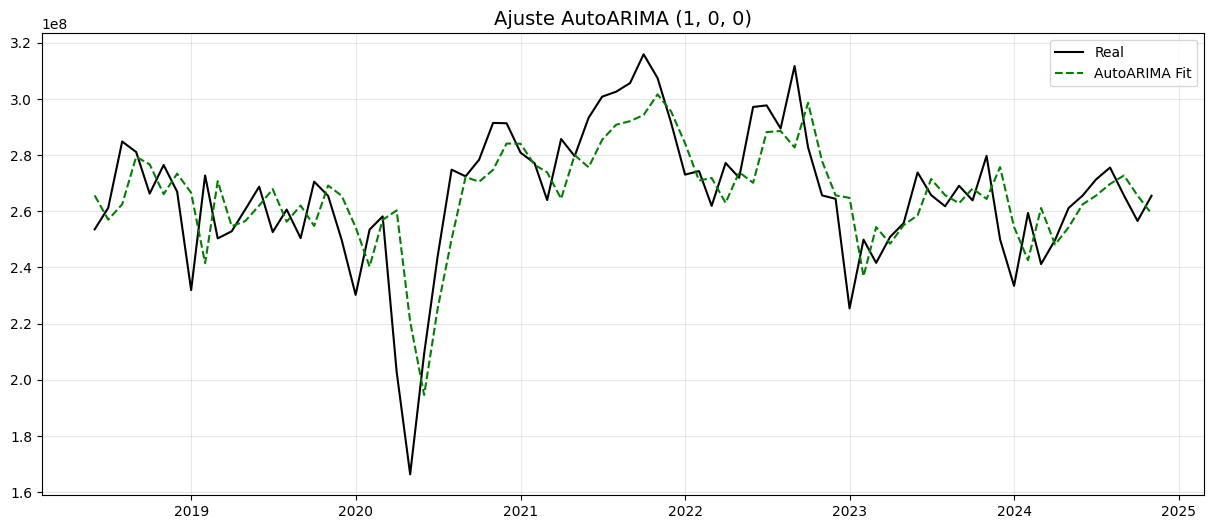

In [78]:
#Prompt: modelo a série volume industrial utilizando o autoarima
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install pmdarima -q
from pmdarima import auto_arima

# Defining the series
series_volume = df_volume['Volume Industrial']

# Running auto_arima
# stationary=True because our tests (ADF, KPSS) already confirmed it
# seasonal=False as we are treating it as a simple ARIMA for now
auto_model = auto_arima(series_volume,
                        seasonal=False,
                        stationary=True,
                        stepwise=True,
                        suppress_warnings=True,
                        error_action='ignore',
                        trace=True)

print("\nMelhor modelo encontrado pelo auto_arima:")
print(auto_model.summary())

# Visualizing the fit
plt.figure(figsize=(15, 6))
plt.plot(df_volume['Mes'], series_volume, label='Real', color='black')
plt.plot(df_volume['Mes'], auto_model.predict_in_sample(), label='AutoARIMA Fit', color='green', linestyle='--')
plt.title(f'Ajuste AutoARIMA {auto_model.order}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [79]:
#Prompt: calcule rmse e mape do modelo ar(1)
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Get predictions (fitted values) for the AR(1) / ARIMA(1,0,0) model
y_pred_auto = auto_model.predict_in_sample()

# Calculate metrics
rmse_auto = np.sqrt(mean_squared_error(series_volume, y_pred_auto))
mape_auto = mean_absolute_percentage_error(series_volume, y_pred_auto)

# Add to the existing comparison table for clear visibility
new_row = pd.DataFrame({
    'Métrica': ['RMSE', 'MAPE (%)'],
    'ARIMA(1,0,0) [Auto]': [rmse_auto, mape_auto * 100]
})

# Merge with previous metrics if available
if 'metrics_comparison' in globals():
    comparison_final = pd.merge(metrics_comparison, new_row, on='Métrica')
    print("Comparativo de Performance Final (In-sample):")
    display(comparison_final)
else:
    display(new_row)

Comparativo de Performance Final (In-sample):


,Métrica,"ARIMA(4,0,2)","ARIMA(3,0,2)","ARIMA(1,0,0) [Auto]"
0,RMSE,1.659013e+07,1.663954e+07,1.681371e+07
1,MAPE (%),4.957566e+00,4.977980e+00,5.011492e+00


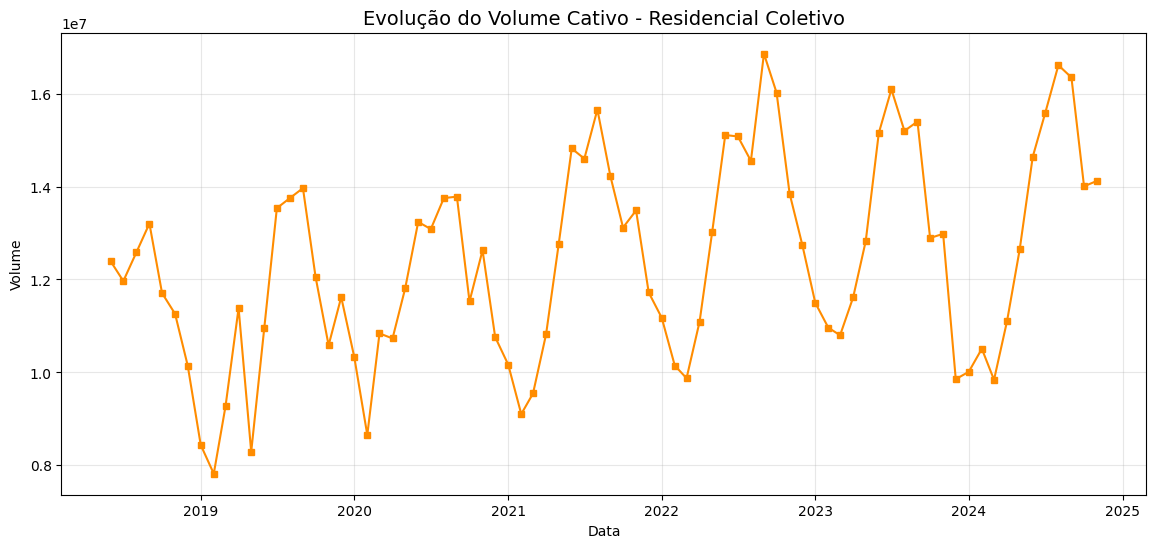

In [80]:
#Prompt: plote a série volmue cativo - residencial coletivo
import matplotlib.pyplot as plt

# Plotting the 'Volume Cativo - Residencial Coletivo' series
plt.figure(figsize=(14, 6))
plt.plot(df_volume['Mes'], df_volume['Volume Cativo - Residencial Coletivo'], color='darkorange', marker='s', linestyle='-', markersize=4)

plt.title('Evolução do Volume Cativo - Residencial Coletivo', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)
plt.show()

In [81]:
#Prompt: teste a estacionariedade com os 4 testes
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron, DFGLS

# Defining the series for Residencial Coletivo
series_residencial = df_volume['Volume Cativo - Residencial Coletivo']

# Function to format results (reusing the same logic for consistency)
def print_residencial_results(name, statistic, p_value, crit_values, null_hypothesis):
    print(f"--- {name} (Residencial Coletivo) ---")
    print(f"Hipotese Nula: {null_hypothesis}")
    print(f"Estatística do Teste: {statistic:.4f}")
    print(f"p-valor: {p_value:.4f}" if p_value is not None else "p-valor: N/A")
    print(f"Valor Crítico (5%): {crit_values['5%']:.4f}")
    print("\n")

# 1. ADF Test
adf_r = adfuller(series_residencial)
print_residencial_results("ADF", adf_r[0], adf_r[1], adf_r[4], "Possui raiz unitária")

# 2. KPSS Test
kpss_r = kpss(series_residencial, regression='c')
print_residencial_results("KPSS", kpss_r[0], kpss_r[1], kpss_r[3], "A série é estacionária")

# 3. Phillips-Perron (PP)
pp_r = PhillipsPerron(series_residencial)
print_residencial_results("Phillips-Perron (PP)", pp_r.stat, pp_r.pvalue, pp_r.critical_values, "Possui raiz unitária")

# 4. DF-GLS
dfgls_r = DFGLS(series_residencial)
print_residencial_results("DF-GLS", dfgls_r.stat, dfgls_r.pvalue, dfgls_r.critical_values, "Possui raiz unitária")

--- ADF (Residencial Coletivo) ---
Hipotese Nula: Possui raiz unitária
Estatística do Teste: -1.9617
p-valor: 0.3036
Valor Crítico (5%): -2.9064


--- KPSS (Residencial Coletivo) ---
Hipotese Nula: A série é estacionária
Estatística do Teste: 0.4524
p-valor: 0.0546
Valor Crítico (5%): 0.4630


--- Phillips-Perron (PP) (Residencial Coletivo) ---
Hipotese Nula: Possui raiz unitária
Estatística do Teste: -2.1475
p-valor: 0.2258
Valor Crítico (5%): -2.8999


--- DF-GLS (Residencial Coletivo) ---
Hipotese Nula: Possui raiz unitária
Estatística do Teste: -1.3255
p-valor: 0.1772
Valor Crítico (5%): -2.2174




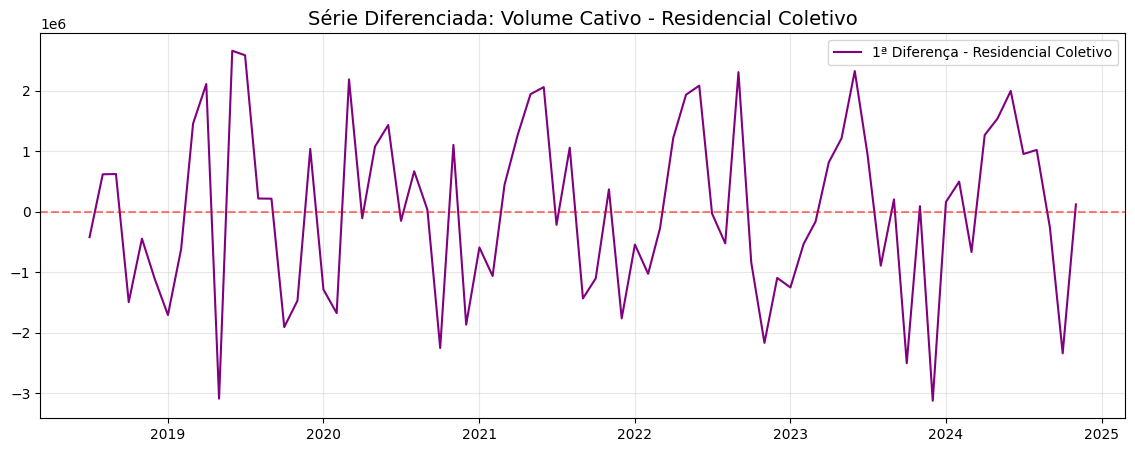

TESTES DE ESTACIONARIEDADE NA SÉRIE DIFERENCIADA:

--- ADF (Série Diferenciada) ---
Hipotese Nula: Possui raiz unitária
Estatística: -6.0603 | p-valor: 0.0000
Valor Crítico (5%): -2.9064

--- KPSS (Série Diferenciada) ---
Hipotese Nula: A série é estacionária
Estatística: 0.0258 | p-valor: 0.1000
Valor Crítico (5%): 0.4630

--- Phillips-Perron (PP) (Série Diferenciada) ---
Hipotese Nula: Possui raiz unitária
Estatística: -10.2753 | p-valor: 0.0000
Valor Crítico (5%): -2.9004

--- DF-GLS (Série Diferenciada) ---
Hipotese Nula: Possui raiz unitária
Estatística: -1.7548 | p-valor: 0.0781
Valor Crítico (5%): -2.2209



/tmp/ipykernel_2549/1660950068.py:33: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff_r = kpss(series_residencial_diff, regression='c')


In [82]:
#Prompt: gere a diferenciação, plote e faça os testes de estacionariedade
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron, DFGLS

# 1. Calculating the First Difference
series_residencial_diff = series_residencial.diff().dropna()

# 2. Plotting the Differentiated Series
plt.figure(figsize=(14, 5))
plt.plot(df_volume['Mes'][1:], series_residencial_diff, color='purple', label='1ª Diferença - Residencial Coletivo')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Série Diferenciada: Volume Cativo - Residencial Coletivo', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 3. Running Stationarity Tests on the Differentiated Series
def print_diff_results(name, statistic, p_value, crit_values, null_hypothesis):
    print(f"--- {name} (Série Diferenciada) ---")
    print(f"Hipotese Nula: {null_hypothesis}")
    print(f"Estatística: {statistic:.4f}" + (f" | p-valor: {p_value:.4f}" if p_value is not None else ""))
    print(f"Valor Crítico (5%): {crit_values['5%']:.4f}\n")

print("TESTES DE ESTACIONARIEDADE NA SÉRIE DIFERENCIADA:\n")

# ADF
adf_diff_r = adfuller(series_residencial_diff)
print_diff_results("ADF", adf_diff_r[0], adf_diff_r[1], adf_diff_r[4], "Possui raiz unitária")

# KPSS
kpss_diff_r = kpss(series_residencial_diff, regression='c')
print_diff_results("KPSS", kpss_diff_r[0], kpss_diff_r[1], kpss_diff_r[3], "A série é estacionária")

# PP
pp_diff_r = PhillipsPerron(series_residencial_diff)
print_diff_results("Phillips-Perron (PP)", pp_diff_r.stat, pp_diff_r.pvalue, pp_diff_r.critical_values, "Possui raiz unitária")

# DF-GLS
dfgls_diff_r = DFGLS(series_residencial_diff)
print_diff_results("DF-GLS", dfgls_diff_r.stat, dfgls_diff_r.pvalue, dfgls_diff_r.critical_values, "Possui raiz unitária")

In [83]:
#Prompt: separe em treino e teste (70/30), e rode o autoarima
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd

# 1. Train/Test Split (70/30)
series_residencial = df_volume['Volume Cativo - Residencial Coletivo']
split_idx = int(len(series_residencial) * 0.7)
train_res = series_residencial.iloc[:split_idx]
test_res = series_residencial.iloc[split_idx:]

print(f"Treino: {len(train_res)} observações")
print(f"Teste: {len(test_res)} observações\n")

# 3. Auto-ARIMA
print("Rodando Auto-ARIMA...")
model_auto_res = auto_arima(train_res,
                            seasonal=True, m=12,
                            suppress_warnings=True,
                            stepwise=True,
                            trace=True)

print("\nMelhor modelo encontrado:")
print(model_auto_res.summary())

Treino: 54 observações
Teste: 24 observações

Rodando Auto-ARIMA...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=1682.244, Time=0.52 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1728.436, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1677.441, Time=0.39 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1699.739, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1918.079, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1683.593, Time=0.02 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=1679.410, Time=0.26 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=1679.327, Time=0.10 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=1679.435, Time=0.08 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=1680.780, Time=0.30 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=1729.976, Time=0.04 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=1680.113, Time=0.10 sec
 ARIMA(1,0,1)(1,0,0)[12] intercept   : AIC=1679.555, Time=0.09 sec
 ARIMA(0,0,1)(1,0,

In [84]:
#Prompt: rode a projeção com o autorima sem rolling window e calcule o erro
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd

# 1. Gerar previsões para o período de teste usando o modelo do auto_arima
# O modelo foi armazenado em 'model_auto_res' na célula anterior
forecast_auto_res = model_auto_res.predict(n_periods=len(test_res))

# 2. Calcular métricas
rmse_auto_res = np.sqrt(mean_squared_error(test_res, forecast_auto_res))
mape_auto_res = mean_absolute_percentage_error(test_res, forecast_auto_res)

# 3. Exibir resultados
metrics_auto = pd.DataFrame({
    'Métrica': ['RMSE', 'MAPE (%)'],
    'Auto-ARIMA Residencial': [rmse_auto_res, mape_auto_res * 100]
})

print("Desempenho do Auto-ARIMA (Conjunto de Teste):")
display(metrics_auto)

Desempenho do Auto-ARIMA (Conjunto de Teste):


,Métrica,Auto-ARIMA Residencial
0,RMSE,1.777079e+06
1,MAPE (%),1.081081e+01


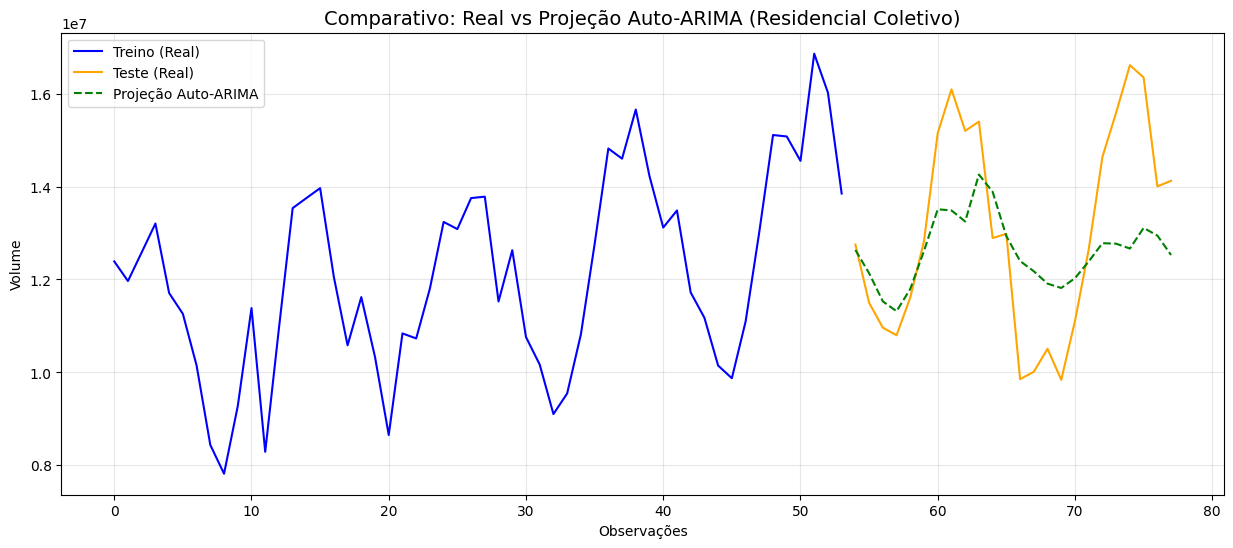

In [85]:
#Prompt: plote real e projeção
import matplotlib.pyplot as plt

# Criando a figura
plt.figure(figsize=(15, 6))

# Plotando dados de treino e teste reais
plt.plot(train_res.index, train_res, label='Treino (Real)', color='blue')
plt.plot(test_res.index, test_res, label='Teste (Real)', color='orange')

# Plotando a previsão do Auto-ARIMA (armazenada em forecast_auto_res)
plt.plot(test_res.index, forecast_auto_res, label='Projeção Auto-ARIMA', color='green', linestyle='--')

# Configurações do gráfico
plt.title('Comparativo: Real vs Projeção Auto-ARIMA (Residencial Coletivo)', fontsize=14)
plt.xlabel('Observações')
plt.ylabel('Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

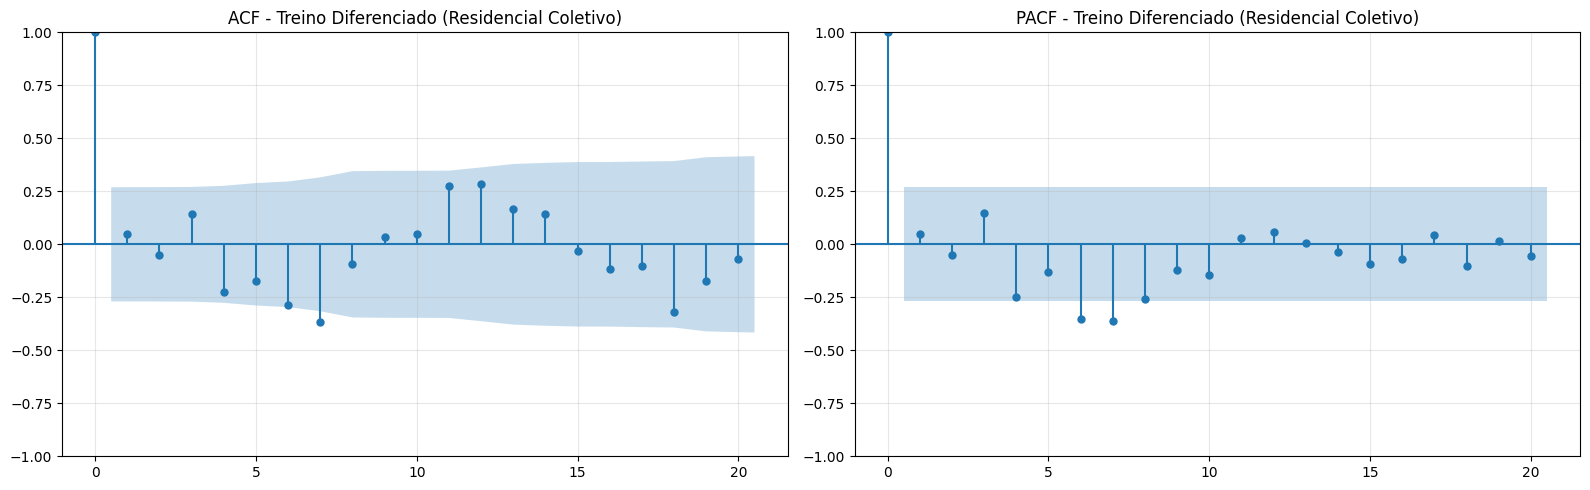

In [86]:
#Prompt: rode o acf e pacf da série diferenciada de treino
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Calculando a primeira diferença da série de treino residencial
train_res_diff = train_res.diff().dropna()

# Configurando a figura para os subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plotando o ACF
plot_acf(train_res_diff, lags=20, ax=axes[0])
axes[0].set_title('ACF - Treino Diferenciado (Residencial Coletivo)')
axes[0].grid(True, alpha=0.3)

# Plotando o PACF
plot_pacf(train_res_diff, lags=20, ax=axes[1], method='ywm')
axes[1].set_title('PACF - Treino Diferenciado (Residencial Coletivo)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


                                        SARIMAX Results                                         
Dep. Variable:     Volume Cativo - Residencial Coletivo   No. Observations:                   54
Model:                  SARIMAX(3, 0, 3)x(1, 0, [], 12)   Log Likelihood                -835.572
Date:                                  Thu, 14 May 2026   AIC                           1687.144
Time:                                          02:42:57   BIC                           1703.056
Sample:                                               0   HQIC                          1693.280
                                                   - 54                                         
Covariance Type:                                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4760      0.111     -4.295      0.000      -0.693

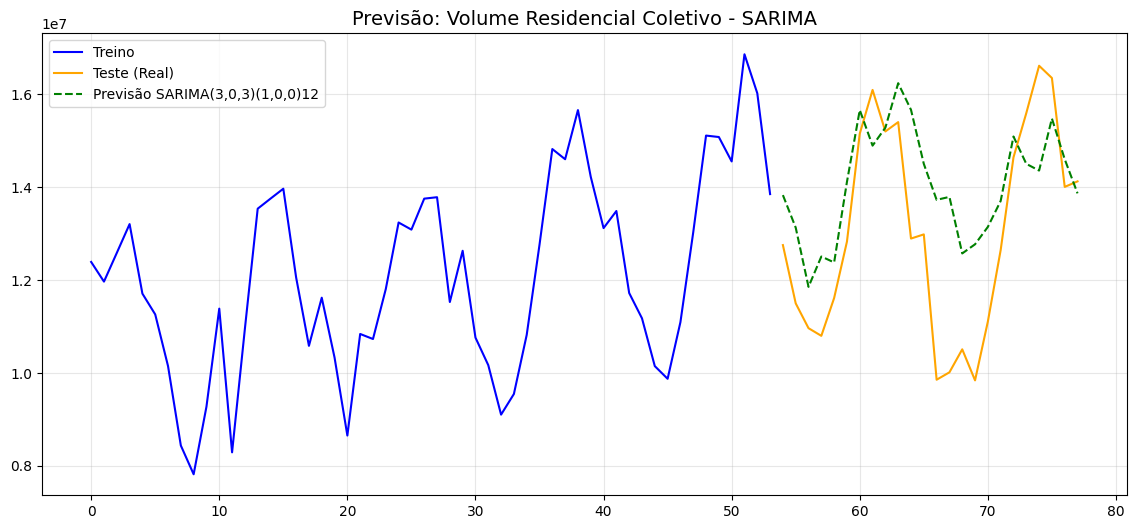

In [87]:
#Prompt: rode um arima(3,3)
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Ajustando o modelo SARIMA(3,0,3)x(1,0,0,12)
# Incluímos o componente sazonal (1,0,0,12) para captar padrões anuais
model_sarima = SARIMAX(train_res,
                       order=(3, 0, 3),
                       seasonal_order=(1, 0, 0, 12))
model_fit_sarima = model_sarima.fit(disp=False)

# Exibindo o sumário do modelo
print(model_fit_sarima.summary())

# Gerando a previsão para o período de teste
forecast_sarima = model_fit_sarima.forecast(steps=len(test_res))

# Plotagem do Comparativo
plt.figure(figsize=(14, 6))
plt.plot(train_res.index, train_res, label='Treino', color='blue')
plt.plot(test_res.index, test_res, label='Teste (Real)', color='orange')
plt.plot(test_res.index, forecast_sarima, label='Previsão SARIMA(3,0,3)(1,0,0)12', color='green', linestyle='--')

plt.title('Previsão: Volume Residencial Coletivo - SARIMA', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [88]:
#Prompt: calcule os indicadores de erro
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd

# Calculando métricas para o SARIMA
rmse_sarima = np.sqrt(mean_squared_error(test_res, forecast_sarima))
mape_sarima = mean_absolute_percentage_error(test_res, forecast_sarima)

# Criando tabela comparativa
metrics_sarima = pd.DataFrame({
    'Modelo': ['SARIMA(3,0,3)(1,0,0)12'],
    'RMSE': [rmse_sarima],
    'MAPE (%)': [mape_sarima * 100]
})

print("Desempenho no Conjunto de Teste:")
display(metrics_sarima)

Desempenho no Conjunto de Teste:


,Modelo,RMSE,MAPE (%)
0,"SARIMA(3,0,3)(1,0,0)12",1.793554e+06,12.556612
